In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_df_final.csv")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,order_item_id,...,distance_km,delivery_days,delay_days,freight_ratio,seller_recent_delay_avg,product_volume_cm3,is_bad_review,logistics_cluster_1,logistics_cluster_2,logistics_cluster_3
0,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30,5,1.0,...,0.165855,-0.206661,-1.087864,-1.481151,-1.648006,2.499336,0,False,False,False
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06,5,1.0,...,0.212014,0.008857,-0.091481,-1.481151,-0.872621,2.499336,0,False,False,False
2,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09,1,1.0,...,-0.298621,-0.314419,-0.091481,-1.481151,-0.614160,2.499336,1,False,False,False
3,3c655487f0c8e34cde2c7b67de8f08cc,5091c4ca04945991068cfba00258cc58,delivered,2017-02-04 19:06:04,2017-02-04 19:15:39,2017-02-10 09:24:35,2017-03-06 08:28:57,2017-03-13,2,1.0,...,1.966564,1.840759,0.506348,-0.304754,0.833224,0.523733,1,False,False,False
4,eb188a175542057d90b3ca5628b7b5a0,1eda56b47988d592fec945da9ee88c56,delivered,2017-02-18 23:26:24,2017-02-19 01:02:43,2017-02-21 07:07:39,2017-02-23 09:23:57,2017-03-21,4,1.0,...,-0.115653,-0.853214,-1.386779,-0.654770,-0.640006,0.523733,0,False,False,False


In [3]:
# Check dataset shape and column types
print("Dataset shape:", df.shape)
df.info()

# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.head(20)

Dataset shape: (108911, 46)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108911 entries, 0 to 108910
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       108911 non-null  object 
 1   customer_id                    108911 non-null  object 
 2   order_status                   108911 non-null  object 
 3   order_purchase_timestamp       108911 non-null  object 
 4   order_approved_at              108896 non-null  object 
 5   order_delivered_carrier_date   108910 non-null  object 
 6   order_delivered_customer_date  108911 non-null  object 
 7   order_estimated_delivery_date  108911 non-null  object 
 8   review_score                   108911 non-null  int64  
 9   order_item_id                  108911 non-null  float64
 10  product_id                     108911 non-null  object 
 11  seller_id                      108911 non-null  object 
 12  sh

product_photos_qty               1515
product_description_lenght       1515
product_name_lenght              1515
product_category_name            1515
geolocation_zip_code_prefix_x     289
buyer_lat                         289
buyer_lng                         289
seller_lng                        253
seller_lat                        253
geolocation_zip_code_prefix_y     253
order_approved_at                  15
order_delivered_carrier_date        1
customer_city                       0
customer_state                      0
order_id                            0
customer_unique_id                  0
distance_km                         0
delivery_days                       0
delay_days                          0
freight_ratio                       0
dtype: int64

In [4]:
# Define the target variable
# Low rating is defined as review_score <= 3
df["low_rating"] = (df["review_score"] <= 3).astype(int)

# Check target distribution
df["low_rating"].value_counts(normalize=True)

low_rating
0    0.768389
1    0.231611
Name: proportion, dtype: float64

In [5]:
# Drop columns that should not be used for prediction
# review_score is removed because it is used to create the target
drop_cols = [
    "review_score",
    "low_rating"
]

X = df.drop(columns=drop_cols)
y = df["low_rating"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (108911, 45)
Target shape: (108911,)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numeric features: 25
Number of categorical features: 20


In [7]:
# Split the data into training and testing sets
# Stratify keeps the class distribution similar in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (87128, 45)
Testing set: (21783, 45)


In [8]:
# Preprocess numeric features with median imputation
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocess categorical features with most frequent imputation and one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

# Build the Gradient Boosted Trees model pipeline
gbt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

# Train the model
gbt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['order_item_id', 'price',
                                                   'freight_value',
                                                   'product_name_lenght',
                                                   'product_description_lenght',
                                                   'product_photos_qty',
                                                   'product_weight_g',
                                                   'product_length_cm',
                                                   'product_height_cm',
                                                   'product_width_cm',
                                                   'seller_zip_code_prefix',...
                                                   'order_delivered_carrier_date',
                                                   'order_delivered_customer_date',
                                                   'order_estimated_delivery_date',
                                                   'product_id', 'seller_id',
                                                   'shipping_limit_date',
                                                   'product_category_name',
                                                   'seller_city',
                                                   'seller_state',
                                                   'customer_unique_id',
                                                   'customer_city',
                                                   'customer_state',
                                                   'logistics_cluster_1',
                                                   'logistics_cluster_2',
                                                   'logistics_cluster_3'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Generate predictions
y_pred = gbt_model.predict(X_test)
y_prob = gbt_model.predict_proba(X_test)[:, 1]

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9151632006610659
Precision: 1.0
Recall: 0.6336967294350843
F1 Score: 0.7757825770444067
ROC AUC: 0.8621747562651871

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     16738
           1       1.00      0.63      0.78      5045

    accuracy                           0.92     21783
   macro avg       0.95      0.82      0.86     21783
weighted avg       0.92      0.92      0.91     21783



In [13]:
import os

# Create figures directory if it doesn't exist
os.makedirs("../figures", exist_ok=True)

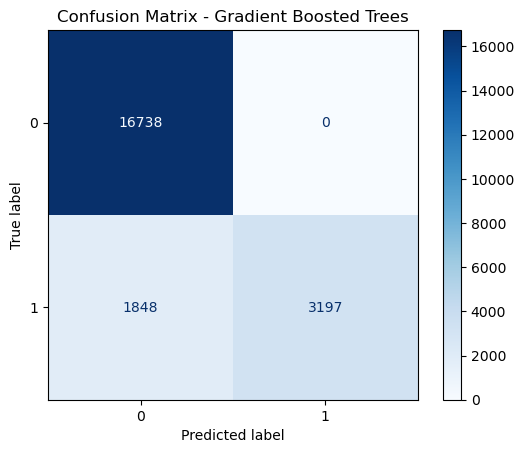

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    gbt_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Gradient Boosted Trees")

# Save figure
plt.savefig("../figures/confusion_matrix_gbt.png", dpi=300, bbox_inches="tight")

plt.show()

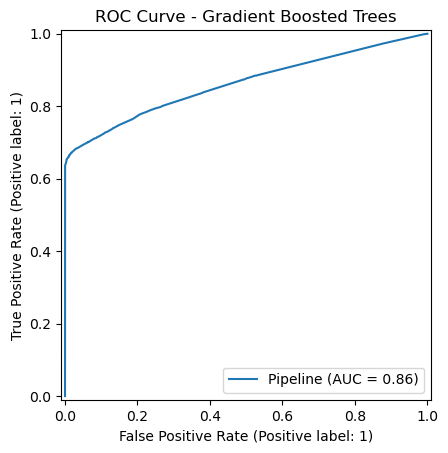

In [15]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve
RocCurveDisplay.from_estimator(
    gbt_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Gradient Boosted Trees")

# Save figure
plt.savefig("../figures/roc_curve_gbt.png", dpi=300, bbox_inches="tight")

plt.show()

In [16]:
# Save model evaluation results
results = pd.DataFrame({
    "Model": ["Gradient Boosted Trees"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "ROC AUC": [roc_auc_score(y_test, y_prob)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosted Trees,0.915163,1.0,0.633697,0.775783,0.862175


In [17]:
# Save results to the project folder
results.to_csv("../reports/gbt_model_results.csv", index=False)

In [18]:
# Get feature names after preprocessing
feature_names = gbt_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance values from the trained classifier
importances = gbt_model.named_steps["classifier"].feature_importances_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

,feature,importance
24,num__is_bad_review,0.966940
19,num__delivery_days,0.009066
20,num__delay_days,0.007889
552768,cat__seller_city_ibitinga,0.001005
0,num__order_item_id,0.000685
622357,cat__customer_unique_id_eae0a83d752b1dd32697e0...,0.000643
628639,cat__customer_city_alto paraiso de goias,0.000606
360318,cat__order_delivered_carrier_date_2018-05-23 1...,0.000313
552798,cat__seller_city_itaquaquecetuba,0.000276
115441,cat__customer_id_7d321bd4e8ba1caf74c4c1aabd9ae524,0.000252


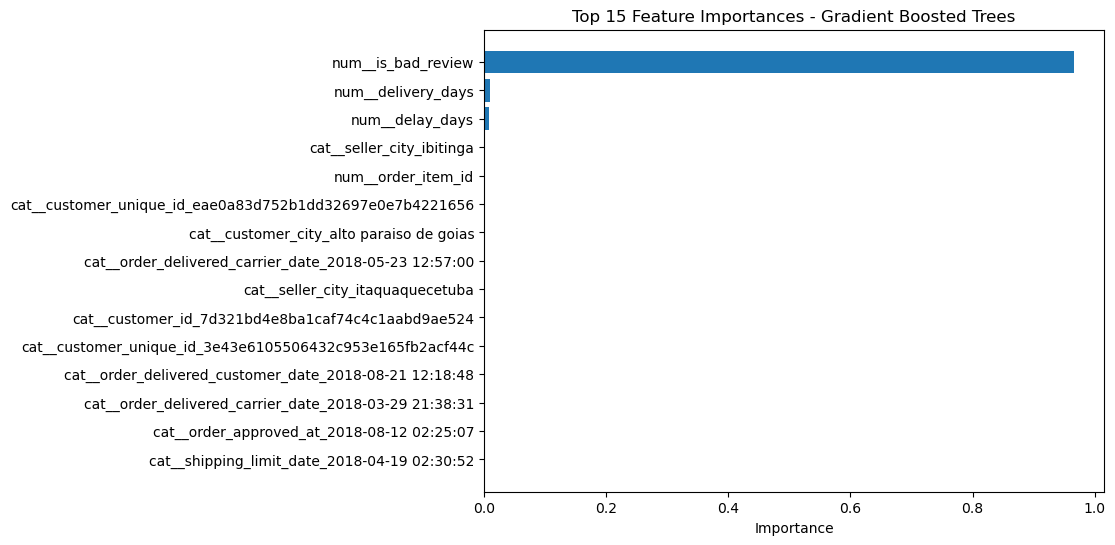

In [19]:
# Plot top 15 feature importances
top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Gradient Boosted Trees")
plt.xlabel("Importance")

# Save figure
plt.savefig("../figures/feature_importance_gbt.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV

# Smaller parameter grid for faster tuning
param_grid_fast = {
    "classifier__n_estimators": [100],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3]
}

grid_search = GridSearchCV(
    estimator=gbt_model,
    param_grid=param_grid_fast,
    scoring="f1",
    cv=2,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 100}
Best CV F1 score: 0.7793710564455948


In [23]:
# Use the best model from grid search
best_gbt_model = grid_search.best_estimator_

# Generate predictions from the tuned model
y_pred_tuned = best_gbt_model.predict(X_test)
y_prob_tuned = best_gbt_model.predict_proba(X_test)[:, 1]

# Evaluate tuned model performance
tuned_results = pd.DataFrame({
    "Model": ["Tuned Gradient Boosted Trees"],
    "Accuracy": [accuracy_score(y_test, y_pred_tuned)],
    "Precision": [precision_score(y_test, y_pred_tuned)],
    "Recall": [recall_score(y_test, y_pred_tuned)],
    "F1 Score": [f1_score(y_test, y_pred_tuned)],
    "ROC AUC": [roc_auc_score(y_test, y_prob_tuned)]
})

tuned_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Tuned Gradient Boosted Trees,0.91498,1.0,0.632904,0.775188,0.860625


In [24]:
# Compare default and tuned model results
model_comparison = pd.concat([results, tuned_results], ignore_index=True)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosted Trees,0.915163,1.0,0.633697,0.775783,0.862175
1,Tuned Gradient Boosted Trees,0.914980,1.0,0.632904,0.775188,0.860625


In [25]:
# Save model comparison results
model_comparison.to_csv("../reports/gbt_model_comparison.csv", index=False)

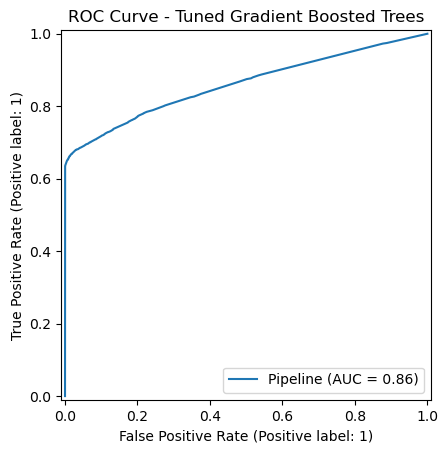

In [26]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot and save tuned model ROC curve
RocCurveDisplay.from_estimator(
    best_gbt_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Tuned Gradient Boosted Trees")
plt.savefig("../figures/roc_curve_tuned_gbt.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Create a short model summary for report writing
summary_text = f"""
Gradient Boosted Trees Model Summary

Target variable:
- low_rating = 1 if review_score <= 3, otherwise 0.

Best model:
- Tuned Gradient Boosted Trees

Performance:
- Accuracy: {tuned_results.loc[0, 'Accuracy']:.4f}
- Precision: {tuned_results.loc[0, 'Precision']:.4f}
- Recall: {tuned_results.loc[0, 'Recall']:.4f}
- F1 Score: {tuned_results.loc[0, 'F1 Score']:.4f}
- ROC AUC: {tuned_results.loc[0, 'ROC AUC']:.4f}
"""

print(summary_text)

# Save summary text
with open("../reports/gbt_model_summary.txt", "w") as f:
    f.write(summary_text)


Gradient Boosted Trees Model Summary

Target variable:
- low_rating = 1 if review_score <= 3, otherwise 0.

Best model:
- Tuned Gradient Boosted Trees

Performance:
- Accuracy: 0.9150
- Precision: 1.0000
- Recall: 0.6329
- F1 Score: 0.7752
- ROC AUC: 0.8606



Exception ignored in: <function ResourceTracker.__del__ at 0x106badc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106fa5c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1060a5c60>
Traceback (most recent call last